product review comments scraper 

## 1. Dependencies & Imports

In [1]:
!pip install youtube-comment-downloader pandas nltk gensim scikit-learn vaderSentiment transformers torch spacy wordcloud matplotlib seaborn --quiet
!python -m spacy download en_core_web_sm --quiet

✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


In [2]:
import re
import unicodedata
from itertools import islice
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import spacy
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from gensim.models import Word2Vec
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from transformers import pipeline
from wordcloud import WordCloud
from youtube_comment_downloader import YoutubeCommentDownloader, SORT_BY_POPULAR

nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

c:\Users\azizn\Desktop\NLP_ESPRIT\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


True

## 3. Configuration

In [67]:
VIDEO_URL = 'https://www.youtube.com/watch?v=ZLyDvABxGF0'
MAX_COMMENTS = 1000
OUTPUT_CSV = 'nlp_dataset.csv'

## 4. Scrape Comments

In [68]:
downloader = YoutubeCommentDownloader()
comments_gen = downloader.get_comments_from_url(VIDEO_URL, sort_by=SORT_BY_POPULAR)

raw_comments = list(islice(comments_gen, MAX_COMMENTS))
print(f'Scraped {len(raw_comments)} comments.')

Scraped 1000 comments.


## 5. Build Dataset

In [69]:
records = [{'comment_id': c.get('cid', ''), 'text': c.get('text', '')} for c in raw_comments]
df = pd.DataFrame(records)

df

,comment_id,text
0,UgyaAHDgTpyEfLrHYqZ4AaABAg,Petition for his voice to become a phone assis...
1,UgwKJWgP0dbYqxmEHSR4AaABAg,Someone: starts doing gang/naruto signs\n\nFac...
2,Ugz1lRXBADlq8GRlMbt4AaABAg,Best breakdown so far. Everyone else is just r...
3,Ugz0tJAXnVM0hDg9yS14AaABAg,YouTube is getting really comfortable with the...
4,UgxkQjDjBr46aUowEwp4AaABAg,"Whenever he says ""I've been using this for aro..."
...,...,...
995,UgzvIZIm_L4XgoOeHxh4AaABAg.9AHcjuVKqeq9AHsaaTrg57,Thats what she said
996,UgzvIZIm_L4XgoOeHxh4AaABAg.9AHcjuVKqeq9AHx36bTa_0,That's what she said
997,UgzvIZIm_L4XgoOeHxh4AaABAg.9AHcjuVKqeq9ATcOQw7gOw,"""straight from Android"" \n-Marques Brownlee, 2..."
998,UgzvIZIm_L4XgoOeHxh4AaABAg.9AHcjuVKqeq9AHgSUEW92f,"""Choti choti magar moti baatein""\n ..."


## 6. Export to CSV

In [70]:
df.to_csv(OUTPUT_CSV, index=False, encoding='utf-8-sig')
print(f'Saved {len(df)} rows to {OUTPUT_CSV}')

Saved 1000 rows to nlp_dataset.csv


---

## Phase 2 — Data Cleaning & Preprocessing for Sentiment Analysis

**Steps:**
1. Reset IDs (1 → n)
2. Normalize text (lowercase, remove URLs / emojis / punctuation / numbers)
3. Remove duplicates & empty rows
4. Remove stop words (multilingual)
5. Tokenization
6. Vectorization — TF-IDF matrix + Word2Vec embeddings
7. Save cleaned dataset

In [71]:
df = pd.read_csv('nlp_dataset.csv', encoding='utf-8-sig')
df.head()

,comment_id,text
0,UgyaAHDgTpyEfLrHYqZ4AaABAg,Petition for his voice to become a phone assis...
1,UgwKJWgP0dbYqxmEHSR4AaABAg,Someone: starts doing gang/naruto signs\n\nFac...
2,Ugz1lRXBADlq8GRlMbt4AaABAg,Best breakdown so far. Everyone else is just r...
3,Ugz0tJAXnVM0hDg9yS14AaABAg,YouTube is getting really comfortable with the...
4,UgxkQjDjBr46aUowEwp4AaABAg,"Whenever he says ""I've been using this for aro..."


In [72]:
df = df.drop(columns=['comment_id'])
df.insert(0, 'comment_id', range(1, len(df) + 1))
df.head()

,comment_id,text
0,1,Petition for his voice to become a phone assis...
1,2,Someone: starts doing gang/naruto signs\n\nFac...
2,3,Best breakdown so far. Everyone else is just r...
3,4,YouTube is getting really comfortable with the...
4,5,"Whenever he says ""I've been using this for aro..."


In [73]:
STOP_WORDS = set()
for lang in ('english', 'french', 'portuguese', 'arabic'):
    try:
        STOP_WORDS.update(stopwords.words(lang))
    except OSError:
        pass

def clean_text(text: str) -> str:
    if not isinstance(text, str):
        return ''
    text = text.lower()
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'[@#]\w+', '', text)
    text = re.sub(r'\b\d{1,2}:\d{2}(?::\d{2})?\b', '', text)
    text = unicodedata.normalize('NFKD', text)
    text = text.encode('ascii', 'ignore').decode('ascii')
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['text_clean'] = df['text'].apply(clean_text)
df[['text', 'text_clean']].head(5)

,text,text_clean
0,Petition for his voice to become a phone assis...,petition for his voice to become a phone assis...
1,Someone: starts doing gang/naruto signs\n\nFac...,someone starts doing gang naruto signs facetim...
2,Best breakdown so far. Everyone else is just r...,best breakdown so far everyone else is just re...
3,YouTube is getting really comfortable with the...,youtube is getting really comfortable with the...
4,"Whenever he says ""I've been using this for aro...",whenever he says i ve been using this for arou...


In [74]:
### 12. Remove Duplicates & Empty Rows
before = len(df)

df = df.drop_duplicates(subset='text_clean')
df = df[df['text_clean'].str.strip().astype(bool)]  # drop empty/whitespace-only

# Re-index comment_id after deduplication
df = df.reset_index(drop=True)
df['comment_id'] = range(1, len(df) + 1)

print(f'Removed {before - len(df)} rows (duplicates / empty). Remaining: {len(df)}')

Removed 63 rows (duplicates / empty). Remaining: 937


In [75]:
def tokenize_and_filter(text: str) -> list[str]:
    tokens = word_tokenize(text)
    return [t for t in tokens if t not in STOP_WORDS and len(t) > 1]

df['tokens'] = df['text_clean'].apply(tokenize_and_filter)
df['text_filtered'] = df['tokens'].apply(lambda toks: ' '.join(toks))
df[['text_clean', 'tokens']].head(5)

,text_clean,tokens
0,petition for his voice to become a phone assis...,"[petition, voice, become, phone, assistant]"
1,someone starts doing gang naruto signs facetim...,"[someone, starts, gang, naruto, signs, facetim..."
2,best breakdown so far everyone else is just re...,"[best, breakdown, far, everyone, else, reitera..."
3,youtube is getting really comfortable with the...,"[youtube, getting, really, comfortable, double..."
4,whenever he says i ve been using this for arou...,"[whenever, says, using, around, expect, say, w..."


In [76]:
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=2)
tfidf_matrix = tfidf.fit_transform(df['text_filtered'])
print(f'TF-IDF matrix: {tfidf_matrix.shape}')

TF-IDF matrix: (937, 1179)


In [77]:
w2v_model = Word2Vec(
    sentences=df['tokens'].tolist(),
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    epochs=10,
    seed=42,
)

def mean_embedding(tokens: list[str], model: Word2Vec) -> np.ndarray:
    vecs = [model.wv[t] for t in tokens if t in model.wv]
    return np.mean(vecs, axis=0) if vecs else np.zeros(model.vector_size)

df['w2v_embedding'] = df['tokens'].apply(lambda t: mean_embedding(t, w2v_model))
print(f'Word2Vec — vocab: {len(w2v_model.wv)}, dim: {w2v_model.vector_size}')

Word2Vec — vocab: 916, dim: 100


In [78]:
cleaned_csv = 'nlp_cleaned.csv'
df[['comment_id', 'text', 'text_clean', 'text_filtered', 'tokens']].to_csv(
    cleaned_csv, index=False, encoding='utf-8-sig'
)
print(f'Cleaned CSV → {cleaned_csv}  ({len(df)} rows)')

Cleaned CSV → nlp_cleaned.csv  (937 rows)


---

## Phase 3 — Sentiment Analysis, Topic Modelling & NER

**Steps:**
1. VADER — rule-based sentiment (positive / negative / neutral)
2. DistilBERT — transformer-based sentiment (positive / negative)
3. VADER vs DistilBERT agreement
4. LDA — topic modelling (5 topics)
5. NER — named entity recognition (ORG, PRODUCT, PERSON, GPE)
6. Save final results

In [79]:
### 17. Load Cleaned Dataset
df = pd.read_csv('nlp_cleaned.csv', encoding='utf-8-sig')
df['tokens'] = df['tokens'].apply(eval)   # restore list from string
print(f'Loaded {len(df)} rows')
df.head(3)

Loaded 937 rows


,comment_id,text,text_clean,text_filtered,tokens
0,1,Petition for his voice to become a phone assis...,petition for his voice to become a phone assis...,petition voice become phone assistant,"[petition, voice, become, phone, assistant]"
1,2,Someone: starts doing gang/naruto signs\n\nFac...,someone starts doing gang naruto signs facetim...,someone starts gang naruto signs facetime move...,"[someone, starts, gang, naruto, signs, facetim..."
2,3,Best breakdown so far. Everyone else is just r...,best breakdown so far everyone else is just re...,best breakdown far everyone else reiterating d...,"[best, breakdown, far, everyone, else, reitera..."


In [80]:
### 18. VADER Sentiment
# Uses text_clean — preserves word meaning without emojis/URLs
vader = SentimentIntensityAnalyzer()

def vader_sentiment(text):
    score = vader.polarity_scores(str(text))['compound']
    label = 'positive' if score >= 0.05 else ('negative' if score <= -0.05 else 'neutral')
    return label, round(score, 4)

results = df['text_clean'].apply(vader_sentiment)
df['vader_label'] = results.apply(lambda x: x[0])
df['vader_score'] = results.apply(lambda x: x[1])

print('VADER distribution:')
print(df['vader_label'].value_counts().to_string())
df[['text_clean', 'vader_label', 'vader_score']].head(5)

VADER distribution:
vader_label
positive    401
neutral     391
negative    145


,text_clean,vader_label,vader_score
0,petition for his voice to become a phone assis...,neutral,0.0000
1,someone starts doing gang naruto signs facetim...,positive,0.2023
2,best breakdown so far everyone else is just re...,positive,0.6369
3,youtube is getting really comfortable with the...,positive,0.5563
4,whenever he says i ve been using this for arou...,neutral,0.0000


In [81]:
### 19. DistilBERT Sentiment
# Binary classifier (positive / negative) — downloads ~260 MB on first run
# Uses CPU by default; set device=0 for GPU
distilbert_pipe = pipeline(
    'sentiment-analysis',
    model='distilbert-base-uncased-finetuned-sst-2-english',
    truncation=True,
    max_length=512,
    device=-1,
)

texts = [t if str(t).strip() else 'empty' for t in df['text_clean'].fillna('')]
bert_out = distilbert_pipe(texts, batch_size=32)

df['distilbert_label'] = [r['label'].lower() for r in bert_out]
df['distilbert_score'] = [round(r['score'], 4) for r in bert_out]

print('DistilBERT distribution:')
print(df['distilbert_label'].value_counts().to_string())
df[['text_clean', 'distilbert_label', 'distilbert_score']].head(5)

Loading weights: 100%|██████████| 104/104 [00:00<00:00, 2794.47it/s]


DistilBERT distribution:
distilbert_label
negative    613
positive    324


,text_clean,distilbert_label,distilbert_score
0,petition for his voice to become a phone assis...,negative,0.9957
1,someone starts doing gang naruto signs facetim...,positive,0.9748
2,best breakdown so far everyone else is just re...,negative,0.9791
3,youtube is getting really comfortable with the...,positive,0.5650
4,whenever he says i ve been using this for arou...,negative,0.9969


In [82]:
### 20. VADER vs DistilBERT Agreement
# Compare only on rows where VADER is not neutral (DistilBERT has no neutral class)
mask = df['vader_label'] != 'neutral'
agreement = (df.loc[mask, 'vader_label'] == df.loc[mask, 'distilbert_label']).mean()
print(f'Agreement on non-neutral rows ({mask.sum()} / {len(df)}): {agreement:.1%}')

print('\nSide-by-side distribution:')
pd.DataFrame({
    'VADER': df['vader_label'].value_counts(),
    'DistilBERT': df['distilbert_label'].value_counts(),
}).fillna(0).astype(int)

Agreement on non-neutral rows (546 / 937): 59.2%

Side-by-side distribution:


,VADER,DistilBERT
negative,145,613
neutral,391,0
positive,401,324


In [83]:
### 21. LDA Topic Modelling
cv = CountVectorizer(max_features=3000, min_df=2)
dtm = cv.fit_transform(df['text_filtered'].fillna(''))

lda = LatentDirichletAllocation(n_components=5, random_state=42, max_iter=20)
lda.fit(dtm)

vocab = cv.get_feature_names_out()
print('Top 10 words per topic:\n')
for i, topic in enumerate(lda.components_):
    top_words = [vocab[j] for j in topic.argsort()[-10:][::-1]]
    print(f'  Topic {i+1}: {", ".join(top_words)}')

df['lda_topic'] = lda.transform(dtm).argmax(axis=1) + 1
print(f'\nTopic distribution:\n{df["lda_topic"].value_counts().sort_index().to_string()}')

Top 10 words per topic:

  Topic 1: android, ios, years, apple, already, back, yes, lol, widgets, using
  Topic 2: apple, android, phone, ios, like, iphone, feature, would, finally, features
  Topic 3: get, android, widgets, picture, could, call, like, sound, use, love
  Topic 4: like, people, game, know, exactly, didnt, thing, high, turn, ok
  Topic 5: youtube, siri, premium, google, lmao, still, apple, use, assistant, watch

Topic distribution:
lda_topic
1    297
2    191
3    140
4    142
5    167


In [84]:
### 22. NER — Named Entity Recognition
nlp_ner = spacy.load('en_core_web_sm')
KEEP_LABELS = {'ORG', 'PRODUCT', 'PERSON', 'GPE', 'NORP'}

all_ents = []
for doc in nlp_ner.pipe(df['text_clean'].tolist(), batch_size=64,
                         disable=['tagger', 'parser', 'lemmatizer']):
    for ent in doc.ents:
        if ent.label_ in KEEP_LABELS:
            all_ents.append({'entity': ent.text.title(), 'type': ent.label_})

ner_df = pd.DataFrame(all_ents)
print(f'Total entities found: {len(ner_df)}\n')
ner_df.value_counts().head(20).to_frame('count')

Total entities found: 223



,,count
entity,type,
Android,ORG,26
Don,PERSON,10
Apple,ORG,9
Sony,ORG,7
Samsung,ORG,6
Google,PRODUCT,5
Japanese,NORP,5
Ps,ORG,5
Google,ORG,4


In [86]:
### 23. Save Final Results
output_cols = [
    'comment_id', 'text', 'text_clean',
    'vader_label', 'vader_score',
    'distilbert_label', 'distilbert_score',
    'lda_topic',
]
df[output_cols].to_csv('nlp_results.csv', index=False, encoding='utf-8-sig')

print('nlp_results.csv →', len(df), 'rows')
df[output_cols].head(5)

nlp_results.csv → 937 rows


,comment_id,text,text_clean,vader_label,vader_score,distilbert_label,distilbert_score,lda_topic
0,1,Petition for his voice to become a phone assis...,petition for his voice to become a phone assis...,neutral,0.0000,negative,0.9957,5
1,2,Someone: starts doing gang/naruto signs\n\nFac...,someone starts doing gang naruto signs facetim...,positive,0.2023,positive,0.9748,1
2,3,Best breakdown so far. Everyone else is just r...,best breakdown so far everyone else is just re...,positive,0.6369,negative,0.9791,4
3,4,YouTube is getting really comfortable with the...,youtube is getting really comfortable with the...,positive,0.5563,positive,0.5650,1
4,5,"Whenever he says ""I've been using this for aro...",whenever he says i ve been using this for arou...,neutral,0.0000,negative,0.9969,2


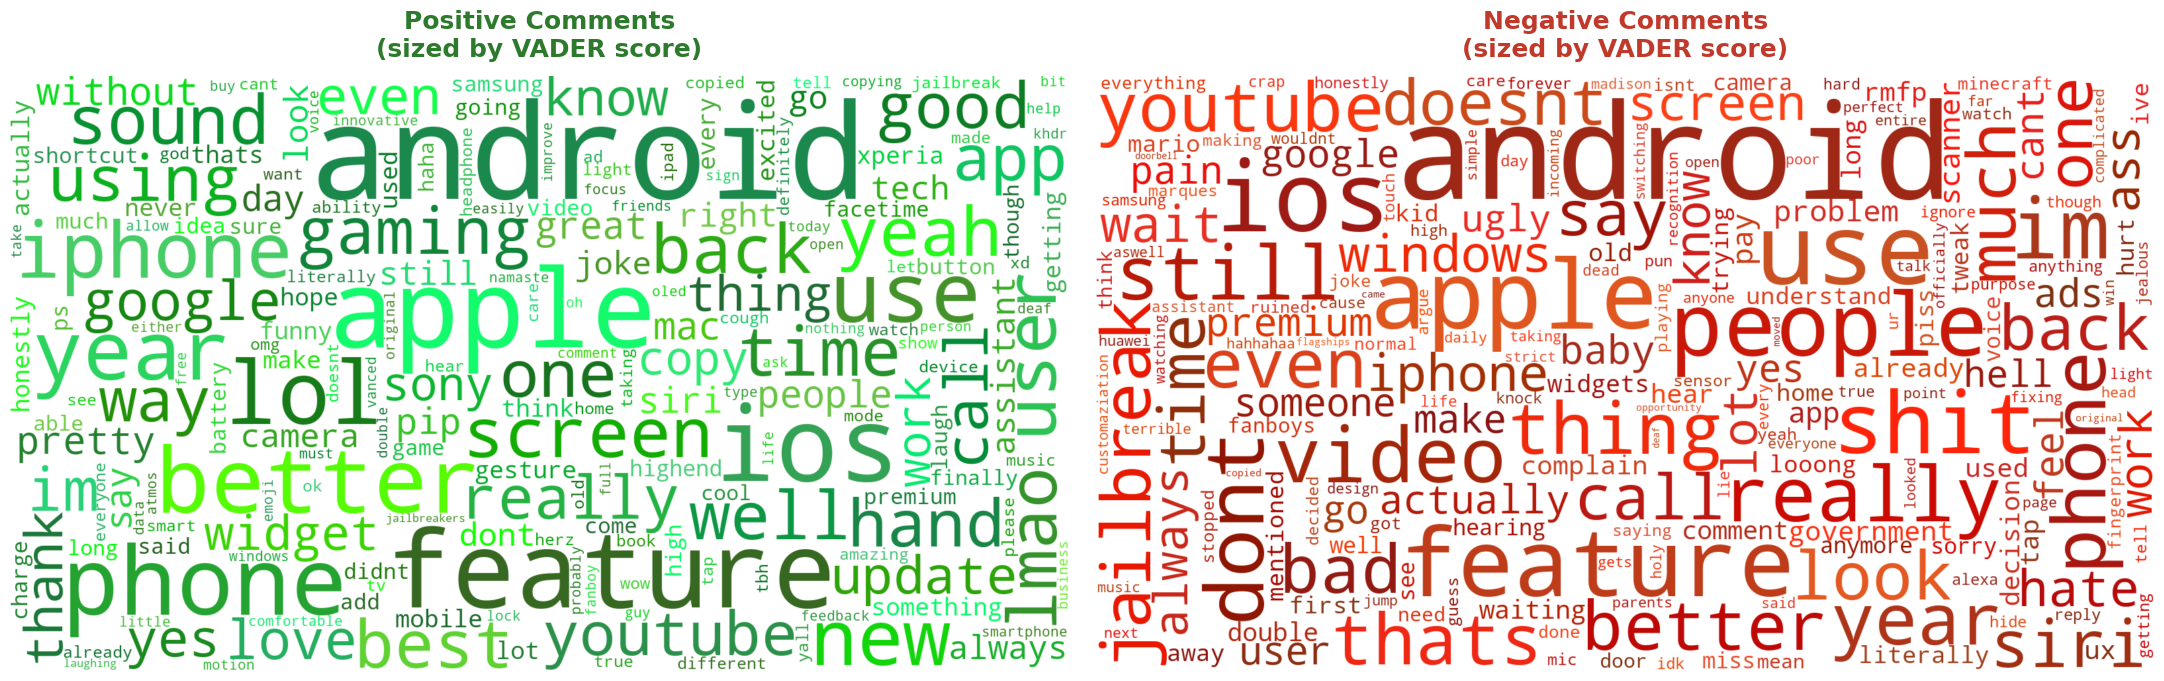

In [88]:
### 25. Word Clouds — weighted by VADER score (highest scorers dominate)

def green_func(word, font_size, position, orientation, random_state=None, **kw):
    return f'hsl({random_state.randint(100, 148)},{random_state.randint(50, 100)}%,{random_state.randint(25, 55)}%)'

def red_func(word, font_size, position, orientation, random_state=None, **kw):
    return f'hsl({random_state.randint(0, 18)},{random_state.randint(70, 100)}%,{random_state.randint(28, 55)}%)'

def weighted_corpus(subset_df, score_col):
    """Repeat each comment's tokens proportionally to its absolute VADER score.
    A comment with score 0.9 is repeated 9×; one with 0.1 only once."""
    parts = []
    for _, row in subset_df.iterrows():
        weight = max(1, round(abs(row[score_col]) * 10))
        text = str(row['text_filtered']) if pd.notna(row['text_filtered']) else ''
        parts.extend([text] * weight)
    return ' '.join(parts)

pos_df = df[df['vader_label'] == 'positive'].dropna(subset=['text_filtered'])
neg_df = df[df['vader_label'] == 'negative'].dropna(subset=['text_filtered'])

pos_corpus = weighted_corpus(pos_df, 'vader_score')
neg_corpus = weighted_corpus(neg_df, 'vader_score')

def make_wc(corpus, color_func):
    return WordCloud(
        width=1600, height=900,
        background_color='white',
        color_func=color_func,
        max_words=200,
        collocations=False,
        prefer_horizontal=0.80,
        relative_scaling=0.5,
        min_font_size=10,
        max_font_size=200,
        random_state=42,
    ).generate(corpus if corpus.strip() else 'no data')

fig, axes = plt.subplots(1, 2, figsize=(22, 10))

axes[0].imshow(make_wc(pos_corpus, green_func), interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Positive Comments\n(sized by VADER score)', fontsize=18, fontweight='bold', color='#2d7a2d', pad=14)

axes[1].imshow(make_wc(neg_corpus, red_func), interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Negative Comments\n(sized by VADER score)', fontsize=18, fontweight='bold', color='#c0392b', pad=14)

plt.tight_layout(pad=2)
plt.savefig('wordclouds_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()